# Bounded Confidence Opinion Dynamics Model

This notebook demonstrates the bounded confidence model featuring two versions.
Both versions interact at random with either:
- All Agents
- Neighbouring agents in a grid

## Model Description

In this model, agents have continuous opinions on [0, 1] and interact in random pairs. When two agents meet:
- If their opinion difference is below threshold $d$, they adjust their opinions
- Opinion adjustment follows: $x = x + \mu(x' - x)$ and $x' = x' + \mu(x - x')$
- Where $\mu$ is the convergence parameter, $d$ is the threshold and $x$ and $x'$ are the opinions of both agents.

This model demonstrates how opinion polarization emerges from simple local interaction rules.

In [138]:
# Install required packages
%pip install mesa seaborn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [114]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mesa import Model, Agent, batch_run
from mesa.discrete_space import CellAgent, OrthogonalVonNeumannGrid
from mesa.datacollection import DataCollector

# Set style for better visualizations
sns.set_theme()

## Part 1: Choose from all Agents (Homogeneous Mixing)

In this version, agents can interact with any other agent in the population, simulating complete mixing.

In [115]:
def get_opinion_groups(model):
    """Count the number of distinct opinion groups based on threshold."""
    epsilon = 0.05
    agents_opinions = [agent.opinion for agent in model.agents]
    agents_opinions.sort()
    return sum(np.diff(agents_opinions) > epsilon) + 1  

In [116]:
class BoundedConfidenceAgent(Agent):
    """An agent that holds an opinion and adjusts it through bounded confidence interactions."""

    def __init__(self, model: Model, opinion: float):
        """
        Create a new bounded confidence agent.

        Args:
            model: The model instance
            opinion: Initial opinion value (0 to 1)
        """
        super().__init__(model)
        self.opinion = opinion

    def step(self):
        """Execute one step: interact with a random agent."""
        # Select a random agent to interact with
        other_agent = self.random.choice(self.model.agents)
        
        # Calculate opinion difference
        opinion_distance = abs(self.opinion - other_agent.opinion)
        
        # Adjust opinions if within threshold
        if opinion_distance < self.model.threshold:
            # Store original opinion to avoid using updated value
            original_other_opinion = other_agent.opinion
            
            # Update both agents' opinions
            other_agent.opinion += self.model.convergence * (self.opinion - other_agent.opinion)
            self.opinion += self.model.convergence * (original_other_opinion - self.opinion)

In [117]:
class BoundedConfidenceModel(Model):
    """Model with homogeneous mixing: all agents can interact with all others."""

    def __init__(self, n_agents: int, threshold: float, convergence: float, seed: int = None):
        """
        Initialize the bounded confidence model.

        Args:
            n_agents: Number of agents
            threshold: Opinion difference threshold (0 to 1)
            convergence: Convergence parameter (0 to 0.5)
            seed: Random seed for reproducibility
        """
        super().__init__(rng=seed)
        self.num_agents = n_agents
        self.threshold = threshold
        self.convergence = convergence

        # Create agents with random initial opinions from uniform distribution [0, 1]
        random_opinions = [self.random.random() for _ in range(self.num_agents)]
        BoundedConfidenceAgent.create_agents(self, self.num_agents, random_opinions)

        # Set up data collection
        self.datacollector = DataCollector(
            model_reporters={"Opinion_groups": get_opinion_groups},
            agent_reporters={"Opinion": "opinion"},
        )
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one step."""
        # Activate all agents in random order
        self.agents.shuffle_do("step")
        # Collect data
        self.datacollector.collect(self)

### Running the Analytical Model

In [118]:
RANDOM_SEED = 42
ROUNDS = 100
AGENTS = 100

# Create and run model with high threshold (convergence expected)
model_high_threshold = BoundedConfidenceModel(n_agents=AGENTS, threshold=0.5, convergence=0.5, seed=RANDOM_SEED)
model_high_threshold.run_for(ROUNDS)

print(f"Number of opinion groups: {get_opinion_groups(model_high_threshold)}")

# Create and run model with low threshold (polarization expected)
model_low_threshold = BoundedConfidenceModel(n_agents=AGENTS, threshold=0.2, convergence=0.5, seed=RANDOM_SEED)
model_low_threshold.run_for(ROUNDS)

print(f"Number of opinion groups: {get_opinion_groups(model_low_threshold)}")

Number of opinion groups: 1
Number of opinion groups: 2


In [119]:
def visualize_opinion_dynamics_multiple(agent_data_list, titles, visualization_steps=[50]):
    """Visualize the opinion dynamics of multiple models in subplots."""
    fig, axes = plt.subplots(nrows=len(agent_data_list), ncols=1, figsize=(10, 4 * len(agent_data_list)))
    
    if len(agent_data_list) == 1:
        axes = [axes]  # Make it iterable for single model case
    
    for i, (agent_data, title, steps) in enumerate(zip(agent_data_list, titles, visualization_steps)):
        ax = axes[i]
        agent_data = agent_data.reset_index()
        
        for agent_id in agent_data['AgentID'].unique():
            agent_opinions = agent_data[agent_data['AgentID'] == agent_id]
            agent_shortened_opinions = agent_opinions[agent_opinions['Step'] <= steps]
            ax.plot(agent_shortened_opinions['Step'], agent_shortened_opinions['Opinion'], alpha=0.5, linewidth=0.5)
        
        ax.set_xlabel('Step')
        ax.set_ylabel('Opinion')
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

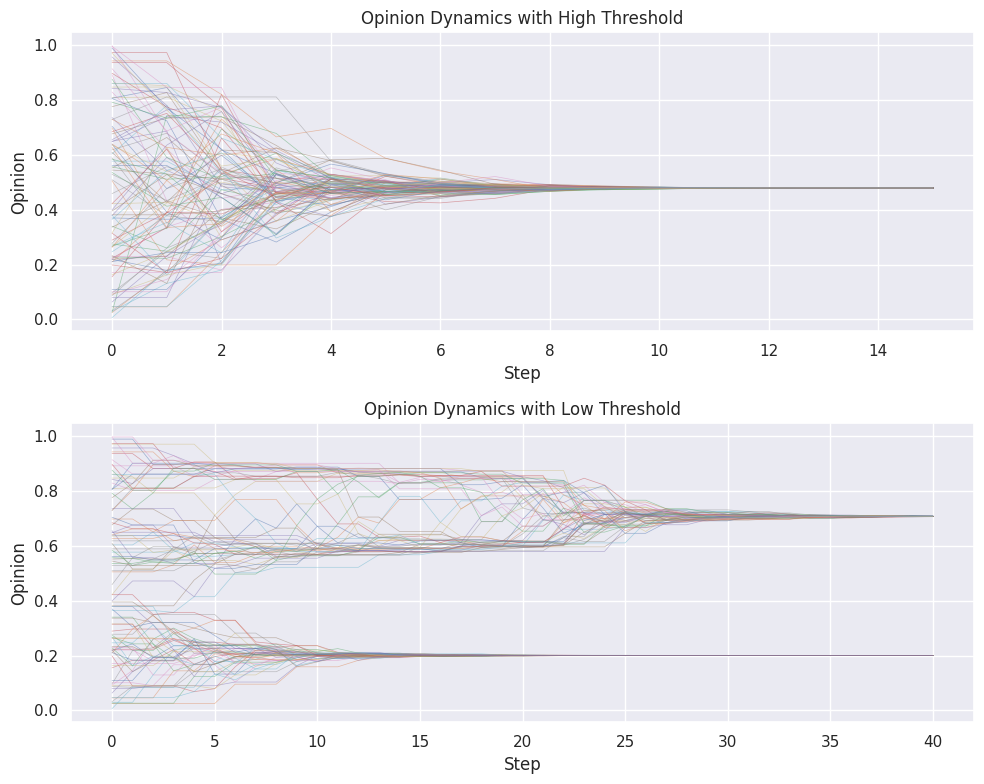

In [120]:
# Visualize both models together using the new function
data_list = [model_high_threshold.datacollector.get_agent_vars_dataframe(), model_low_threshold.datacollector.get_agent_vars_dataframe()]
titles = ["Opinion Dynamics with High Threshold", "Opinion Dynamics with Low Threshold"]
visualization_steps = [15, 40]
visualize_opinion_dynamics_multiple(data_list, titles, visualization_steps)

### Using batch_run for multiple configurations

In [121]:
# batch run with different thresholds
ROUNDS = 100

parameters = {
    "n_agents": [100,500],
    "convergence": 0.5,
    "threshold": [0.2, 0.3, 0.4, 0.5]  # Different thresholds to test
}

results = batch_run(BoundedConfidenceModel, parameters, max_steps=ROUNDS, number_processes=1, data_collection_period=1)

  0%|          | 0/8 [00:00<?, ?it/s]

,RunId,iteration,Step,n_agents,convergence,threshold,seed,Opinion_groups,AgentID,Opinion
0,0,0,0.0,100,0.5,0.2,None,1,1,0.851214
1,0,0,0.0,100,0.5,0.2,None,1,2,0.856817
2,0,0,0.0,100,0.5,0.2,None,1,3,0.290980
3,0,0,0.0,100,0.5,0.2,None,1,4,0.277590
4,0,0,0.0,100,0.5,0.2,None,1,5,0.550556


Number of runs: 8


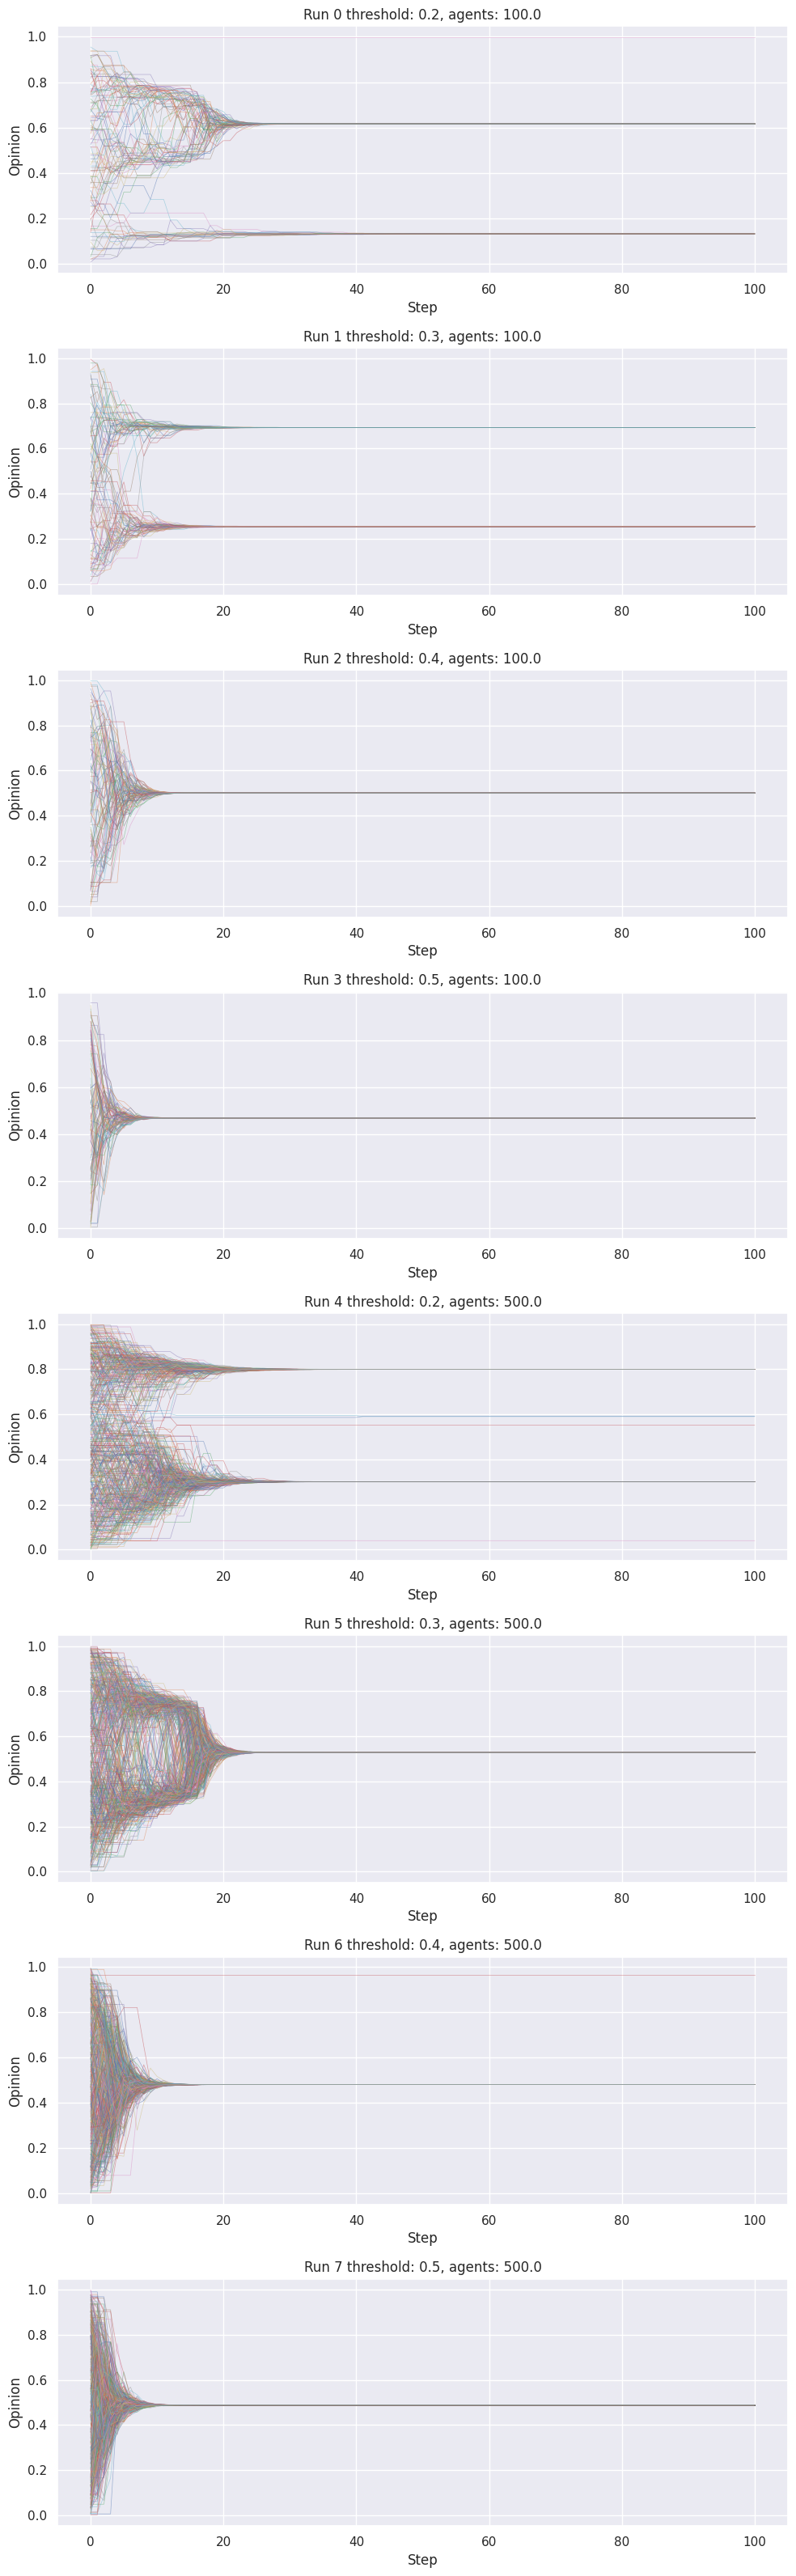

In [122]:
# Convert batch_run results to a DataFrame and group by RunId
results_df = pd.DataFrame(results)
display(results_df.head())

# Create one dataframe per run
run_dataframes = []
for run_id, group in results_df.groupby("RunId"):
    df = group.loc[:, ["Step", "AgentID", "Opinion", "threshold", "n_agents"]].reset_index(drop=True)
    run_dataframes.append(df)

# Example: inspect the first run dataframe
print("Number of runs:", len(run_dataframes))

visualize_opinion_dynamics_multiple(run_dataframes, 
                                    titles=[f"Run {i} threshold: {run_dataframes[i].iloc[0]['threshold']}, agents: {run_dataframes[i].iloc[0]['n_agents']}" for i in range(len(run_dataframes))], 
                                    visualization_steps=[ROUNDS]*len(run_dataframes))

## Part 2: Grid-Based Model (Spatial Interactions)

In this version, agents are placed on a grid and can only interact with their grid neighbors.

In [123]:
class BoundedConfidenceGridAgent(CellAgent):
    """An agent that lives on a grid and interacts with neighbors only."""

    def __init__(self, model: Model, cell, opinion: float):
        """
        Create a new grid-based bounded confidence agent.

        Args:
            model: The model instance
            cell: The grid cell this agent occupies
            opinion: The random opinion value of the agent
        """
        super().__init__(model)
        self.cell = cell
        self.opinion = opinion

    def step(self):
        """Interact with a random neighbor."""
        # Get list of neighbors (von Neumann neighborhood: N, S, E, W)
        neighbors = self.cell.neighborhood.select_random_cell()
        neighbor_agents = [agent for agent in neighbors.agents if agent is not self]
        
        if neighbor_agents:
            other_agent = self.random.choice(neighbor_agents)
            
            # Calculate opinion difference
            opinion_distance = abs(self.opinion - other_agent.opinion)
            
            # Adjust opinions if within threshold
            if opinion_distance < self.model.threshold:
                original_other_opinion = other_agent.opinion
                
                other_agent.opinion += self.model.convergence * (self.opinion - other_agent.opinion)
                self.opinion += self.model.convergence * (original_other_opinion - self.opinion)

In [124]:
def get_opinion_groups(model):
    """Count the number of distinct opinion groups based on threshold."""
    epsilon = 0.05
    agents_opinions = [agent.opinion for agent in model.agents]
    agents_opinions.sort()
    return sum(np.diff(agents_opinions) > epsilon) + 1

In [125]:
class BoundedConfidenceGridModel(Model):
    """Model with spatial structure: agents interact only with grid neighbors."""

    def __init__(self, width: int, height: int, threshold: float, convergence: float, seed: int = None, is_square = False):
        """
        Initialize the grid-based bounded confidence model.

        Args:
            width: Grid width
            height: Grid height
            threshold: Opinion difference threshold (0 to 1)
            convergence: Convergence parameter (0 to 0.5)
            seed: Random seed for reproducibility
            is_square: Determines if only weight is used for both sides
        """
        super().__init__(rng=seed)
        self.width = width
        if is_square:
            self.height = width
        else:
            self.height = height
        self.threshold = threshold
        self.convergence = convergence

        # Create grid
        self.grid = OrthogonalVonNeumannGrid((self.width, self.height), random=self.random)

        # Create one agent per grid cell
        random_opinions = [self.random.random() for _ in range(self.width * self.height)]
        BoundedConfidenceGridAgent.create_agents(self, self.width * self.height, self.grid.all_cells.cells, random_opinions)

        # Set up data collection
        self.datacollector = DataCollector(
            model_reporters={"Opinion_groups": get_opinion_groups,
                             "Opinion_grid": self.get_grid_opinions},
            agent_reporters={"Opinion": "opinion"},
        )
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one step."""
        # Activate all agents in random order
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)
    
    def get_grid_opinions(self):
        opinions_grid = np.zeros((self.width, self.height))
        for cell in self.grid.all_cells.cells:
            if cell.agents:
                opinions_grid[cell.coordinate] = cell.agents[0].opinion
        
        return opinions_grid

### Running the Grid-Based Model

In [126]:
# Create and run grid model
GRID_ROUNDS = 100
grid_model = BoundedConfidenceGridModel(width=20, height=20, threshold=0.3, convergence=0.5)
grid_model.run_for(GRID_ROUNDS)

print(f"Number of opinion groups: {get_opinion_groups(grid_model)}")

Number of opinion groups: 5


In [127]:
def visualize_opinion_dynamics_multiple(agent_data_list, titles, visualization_steps=[50]):
    """Visualize the opinion dynamics of multiple models in subplots."""
    fig, axes = plt.subplots(nrows=len(agent_data_list), ncols=1, figsize=(10, 4 * len(agent_data_list)))
    
    if len(agent_data_list) == 1:
        axes = [axes]  # Make it iterable for single model case
    
    for i, (agent_data, title, steps) in enumerate(zip(agent_data_list, titles, visualization_steps)):
        ax = axes[i]
        agent_data = agent_data.reset_index()
        
        for agent_id in agent_data['AgentID'].unique():
            agent_opinions = agent_data[agent_data['AgentID'] == agent_id]
            agent_shortened_opinions = agent_opinions[agent_opinions['Step'] <= steps]
            ax.plot(agent_shortened_opinions['Step'], agent_shortened_opinions['Opinion'], alpha=0.5, linewidth=0.5)
        
        ax.set_xlabel('Step')
        ax.set_ylabel('Opinion')
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

def visualize_opinion_grid(model_data_list: list[pd.DataFrame], rounds):
    fig, axes = plt.subplots(nrows=len(model_data_list), ncols=3, figsize=(14, 4 * len(model_data_list)))

    if len(model_data_list) == 1:
        axes = [axes]  # Make it iterable for single model case

    for i, model_data in enumerate(model_data_list):
        steps = [2, int(rounds/5), rounds]
        opinions_grids = [model_data.iloc[j-1] for j in steps]

        for col, step, opinions_grid in zip(range(len(steps)), steps, opinions_grids):
            ax = axes[i][col]
            im = ax.imshow(opinions_grid['Opinion_grid'], cmap='RdYlBu_r', vmin=0, vmax=1)
            ax.set_title(f'Spatial Opinion Distribution at step {step}')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Opinion')
    plt.tight_layout()
    plt.show()

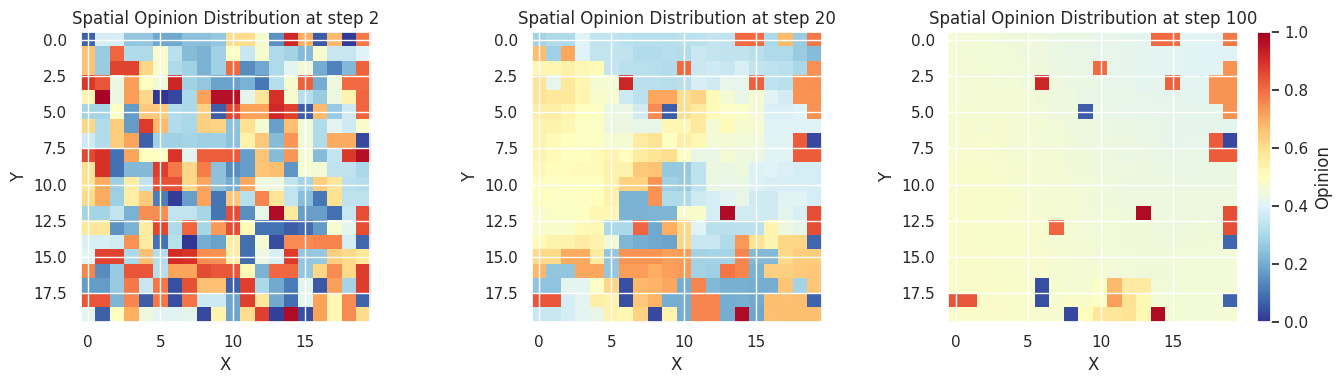

In [ ]:
# Visualize spatial opinion distribution
agent_data = grid_model.datacollector.get_agent_vars_dataframe()
model_data = grid_model.datacollector.get_model_vars_dataframe()

VISUALIZATION_STEPS = 100
visualize_opinion_dynamics_multiple([agent_data], titles=["Opinion Dynamics on Grid"], visualization_steps=[VISUALIZATION_STEPS])
visualize_opinion_grid([model_data], GRID_ROUNDS)

### Using batch_run to run multiple configurations

In [136]:
# batch run with different thresholds
GRID_ROUNDS = 100

parameters = {
    "width": [20, 30, 40],
    "height": 10,
    "convergence": 0.5,
    "threshold": [0.25, 0.35],
    "is_square": True
}

grid_results = batch_run(BoundedConfidenceGridModel, parameters, max_steps=GRID_ROUNDS, number_processes=1, data_collection_period=1)

  0%|          | 0/6 [00:00<?, ?it/s]

Number of runs: 6


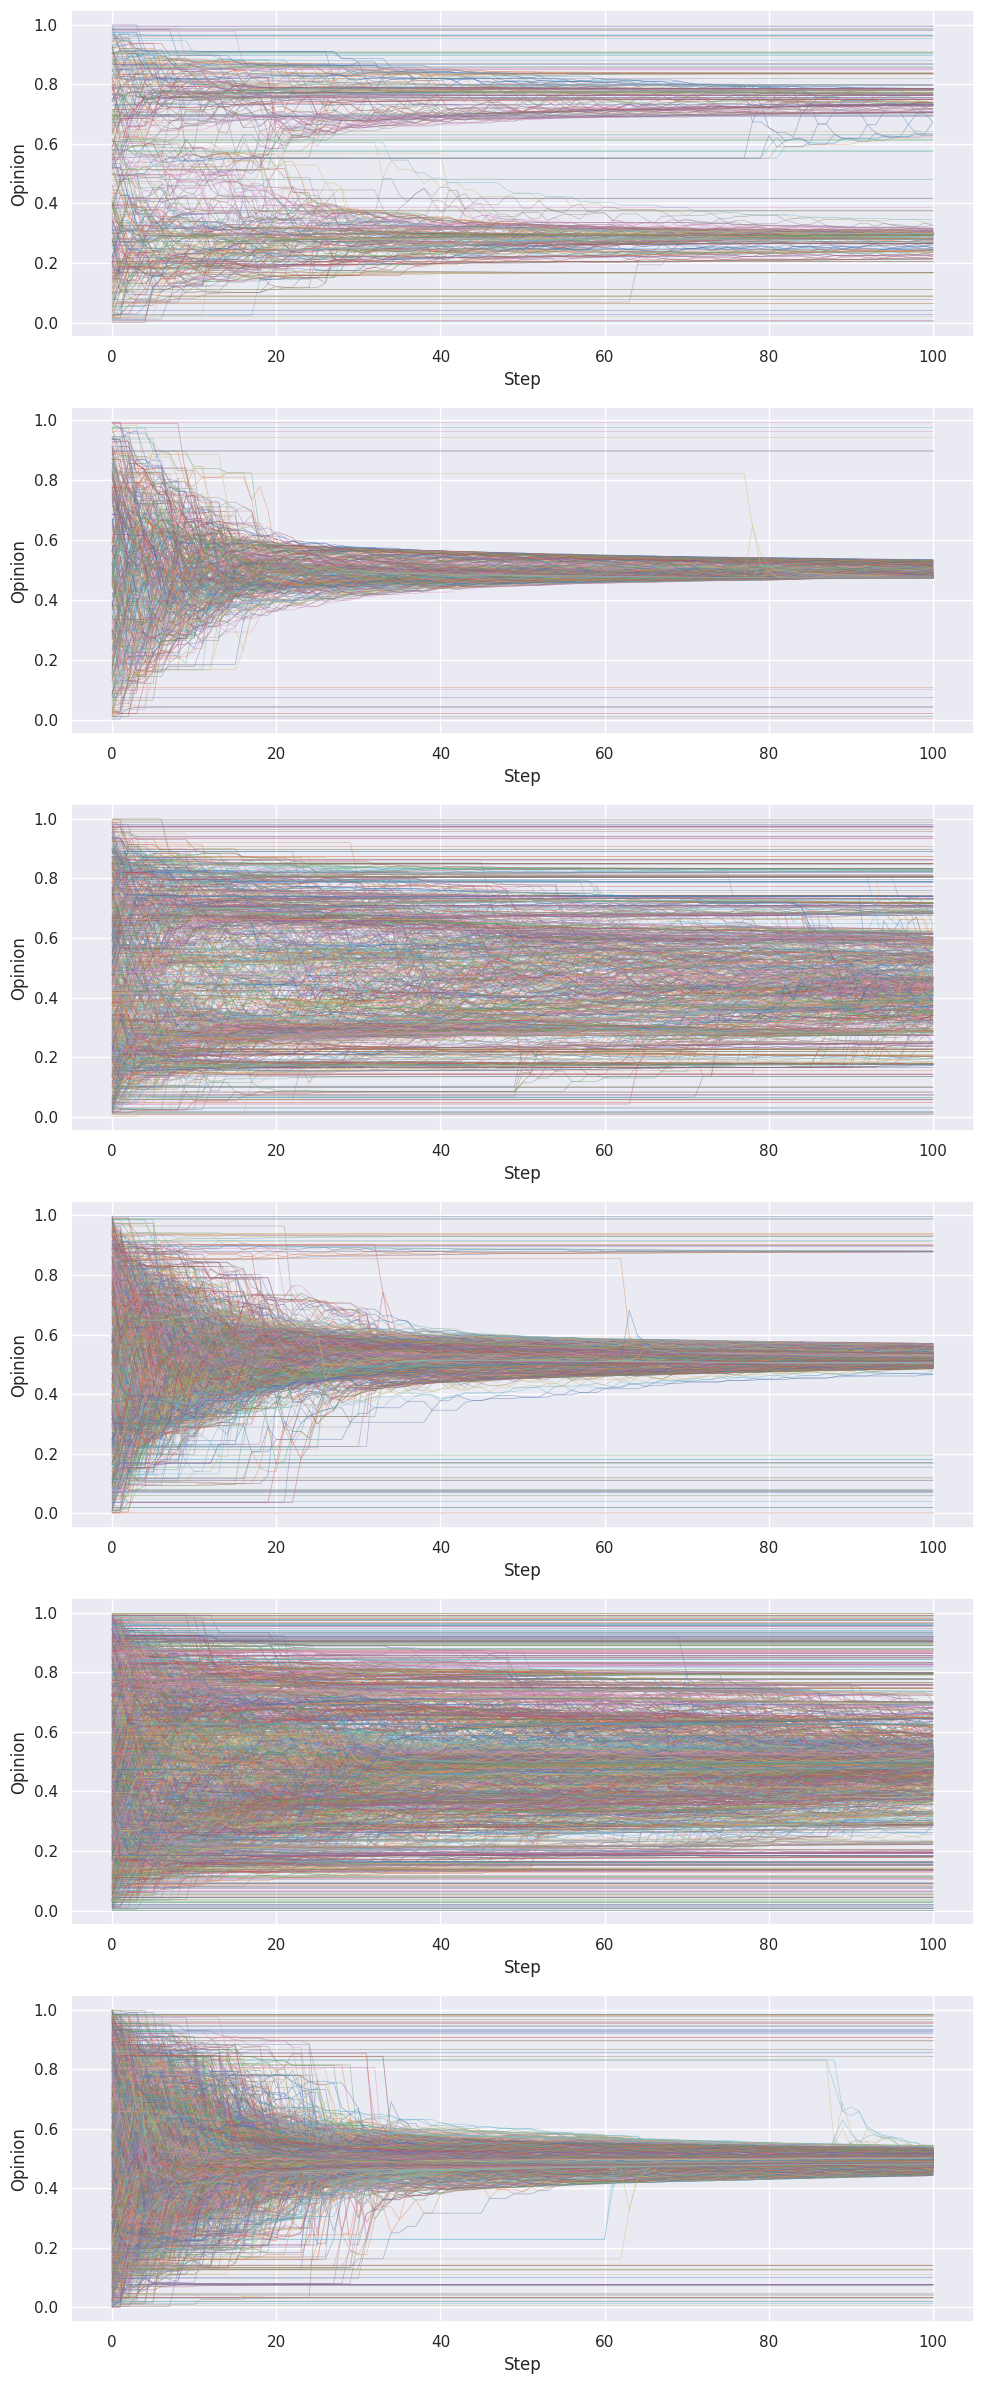

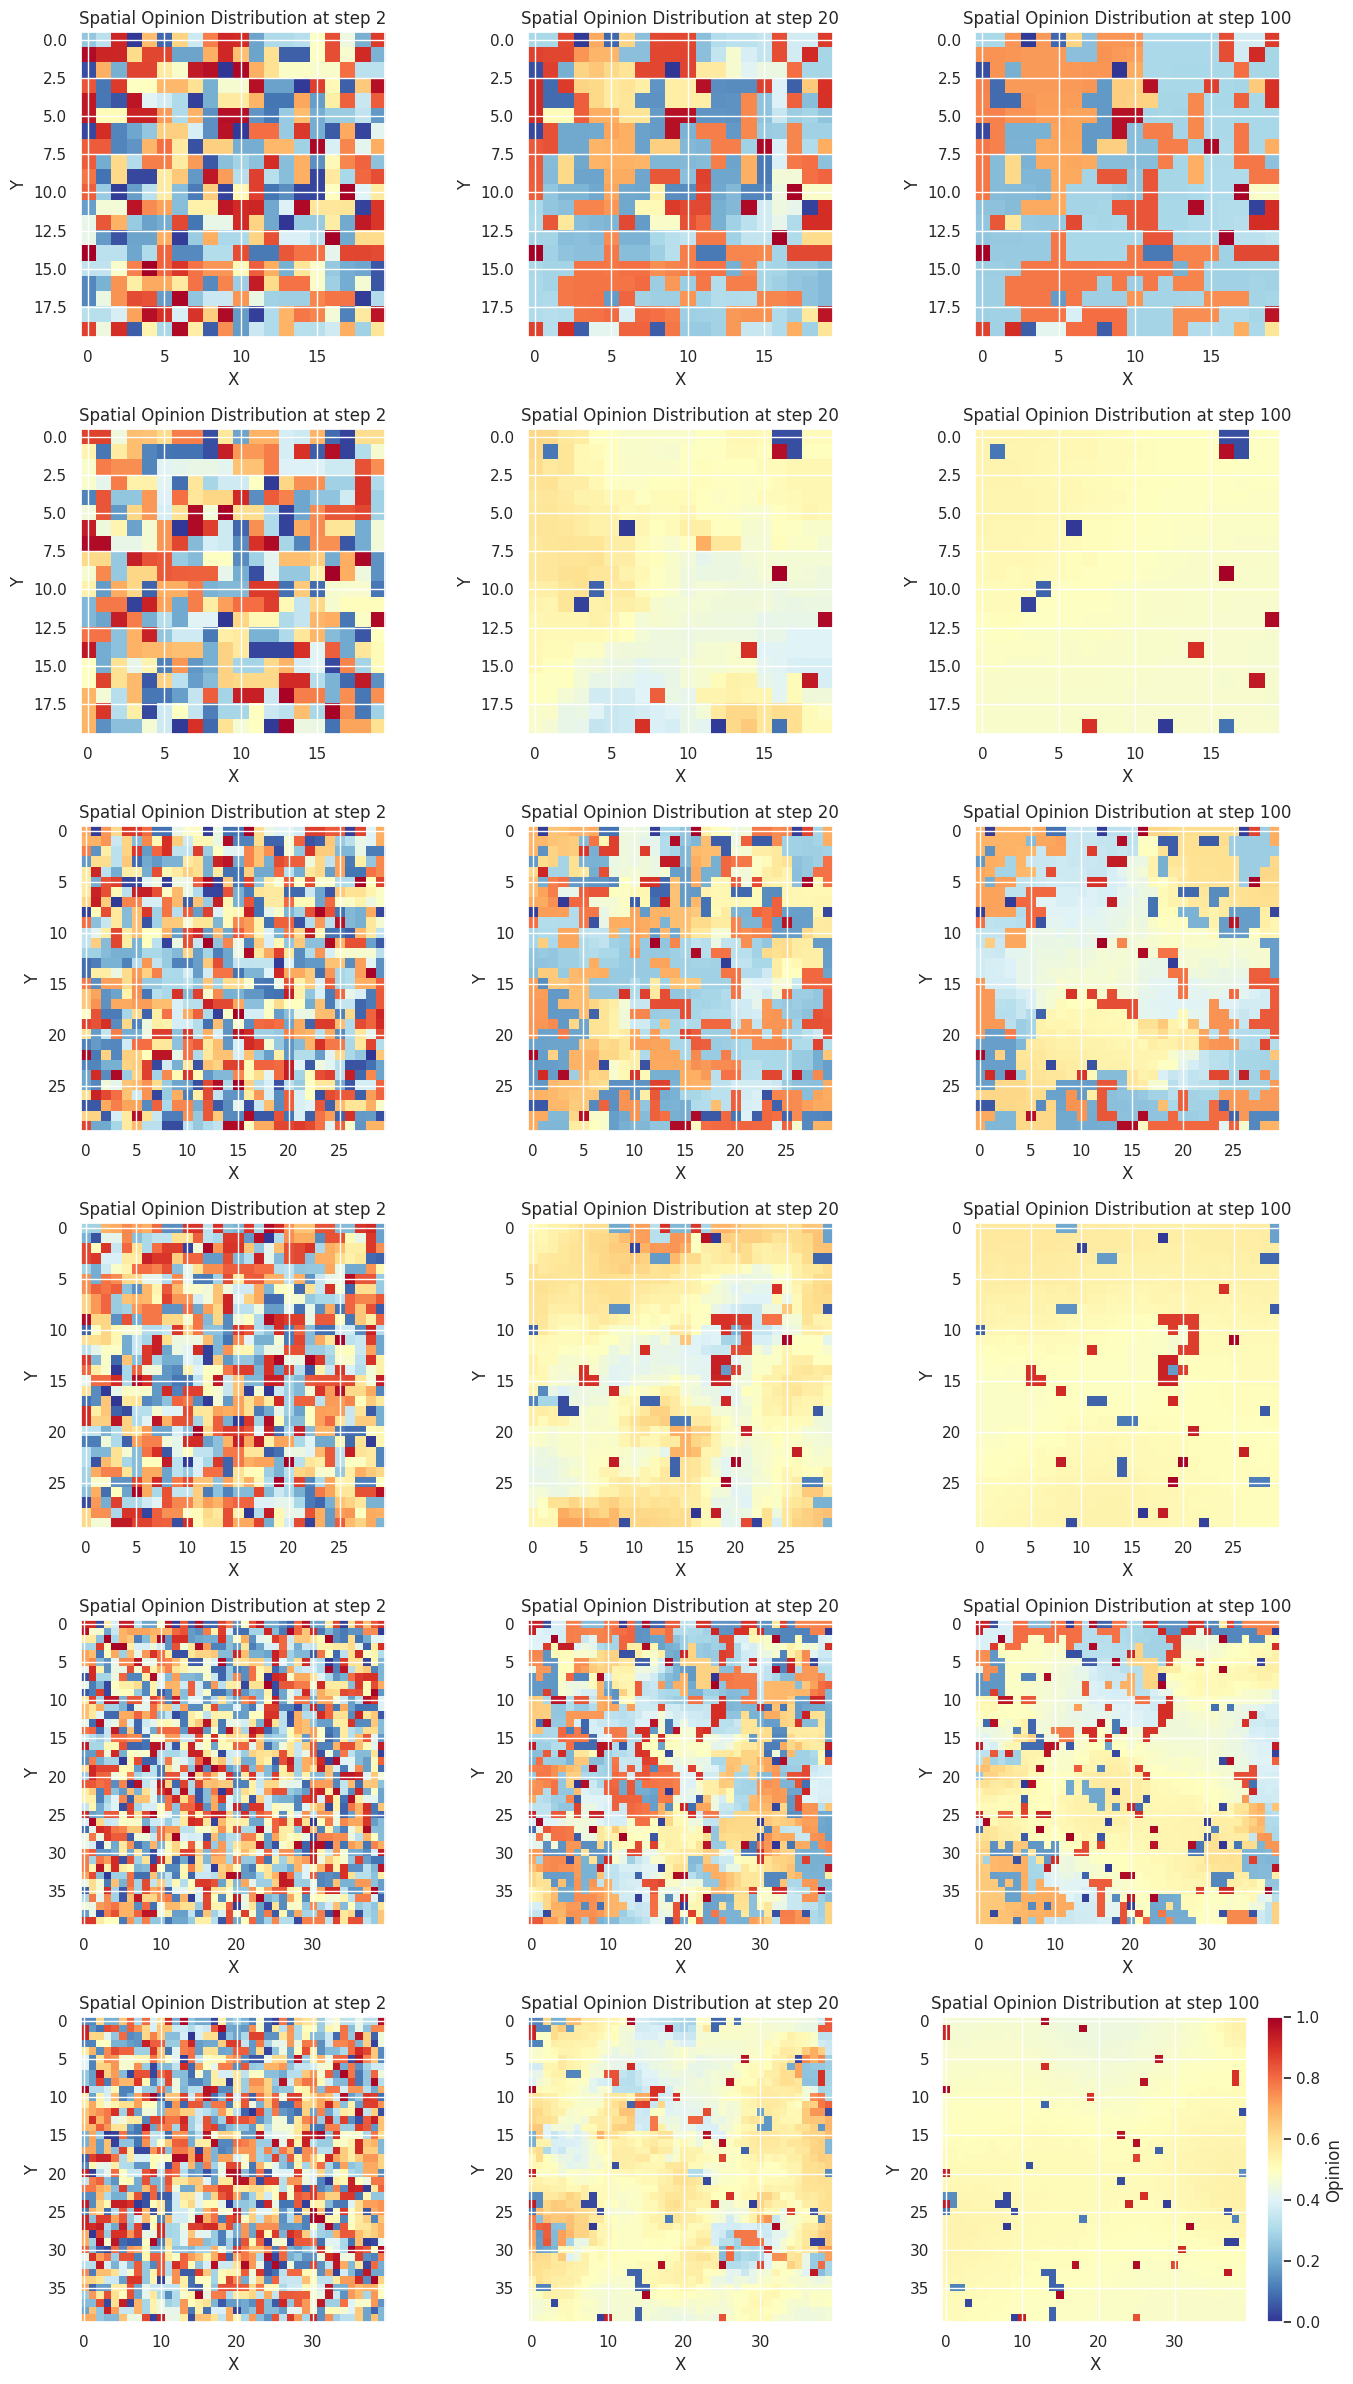

In [137]:
# Convert batch_run results to a DataFrame and group by RunId
grid_results_df = pd.DataFrame(grid_results)

# Create one dataframe per run for model and agent
run_agent_dataframes = []
run_model_dataframes = []
for run_id, group in grid_results_df.groupby("RunId"):
    agent_df = group.loc[:, ["Step", "AgentID", "Opinion", "threshold"]].reset_index(drop=True)
    model_df = group.loc[:, ["Step", "width", "height", "Opinion_grid", "Opinion_groups"]].reset_index(drop=True)
    model_df = model_df.drop_duplicates(subset="Step")
    run_agent_dataframes.append(agent_df)
    run_model_dataframes.append(model_df)

print("Number of runs:", len(run_agent_dataframes))

visualize_opinion_dynamics_multiple(run_agent_dataframes, 
                                    titles=[f"" for _ in range(len(run_agent_dataframes))], 
                                    visualization_steps=[ROUNDS]*len(run_agent_dataframes))

visualize_opinion_grid(run_model_dataframes,
                       rounds=GRID_ROUNDS)

Feel free to modify and play around with the parameters or model however you wish